In [ ]:
!pip install catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,recall_score,confusion_matrix,f1_score,accuracy_score,classification_report,roc_auc_score


warnings.filterwarnings('ignore')

In [ ]:
path = "playground-series-s3e17/"
data = pd.read_csv(path + "train.csv")
data.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [ ]:
test = pd.read_csv(path + "test.csv")
test.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


In [ ]:
print("Training Data Shape:",data.shape)
print("Testing Data Shape:",test.shape)

Training Data Shape: (136429, 14)
Testing Data Shape: (90954, 13)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

# EDA

In [ ]:
value_counts = data['Machine failure'].value_counts()
value_counts

0    134281
1      2148
Name: Machine failure, dtype: int64

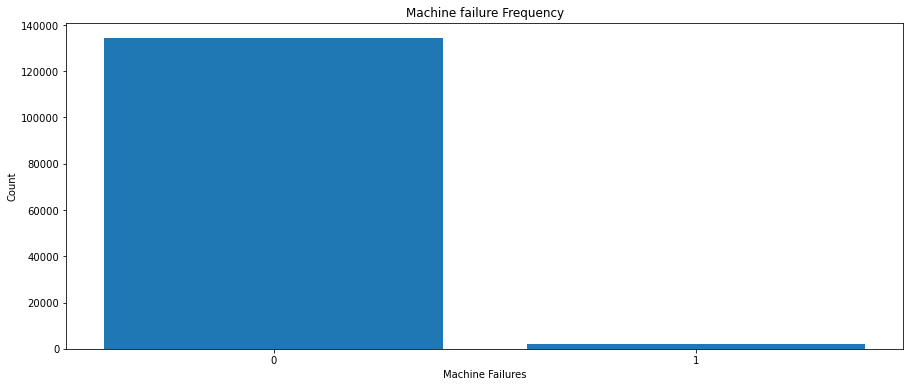

In [ ]:
plt.figure(figsize=(15, 6))
plt.bar(value_counts.index, value_counts.values)
plt.xticks(value_counts.index, ['0', '1'])

plt.xlabel('Machine Failures')
plt.ylabel('Count')
plt.title('Machine failure Frequency')

plt.show()

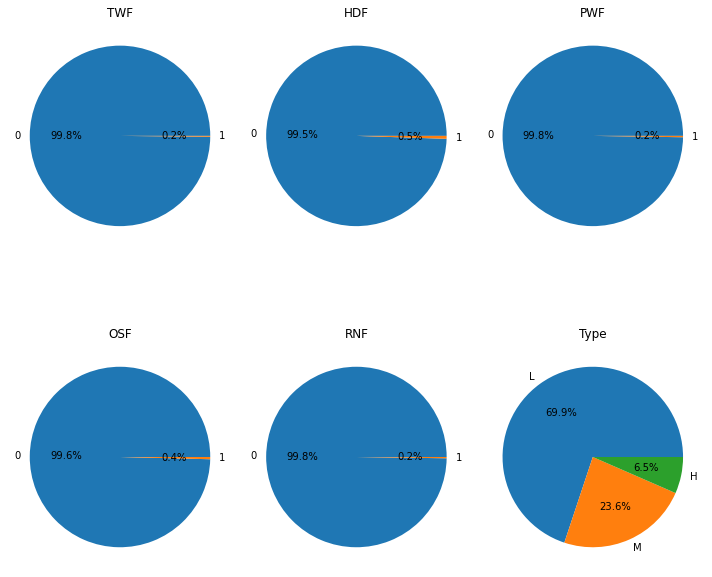

In [ ]:
categorical_columns = ['TWF','HDF','PWF','OSF','RNF','Type']

num_columns = len(categorical_columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(10, 10))

for i, column in enumerate(categorical_columns):
    row = i // 3
    col = i % 3

    value_counts = data[column].value_counts()
    axes[row, col].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%')
    axes[row, col].set_title(column)

plt.tight_layout()
plt.show()

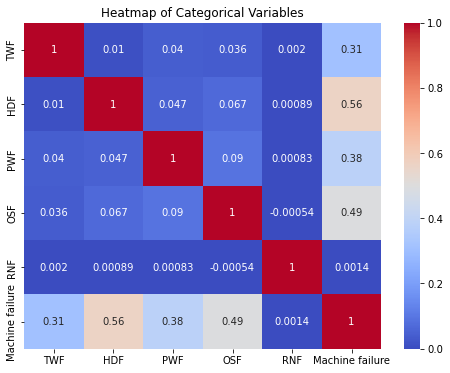

In [ ]:
data_cat = data[categorical_columns+['Machine failure']]

corr_matrix = data_cat.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title('Heatmap of Categorical Variables')

plt.show()


<AxesSubplot:xlabel='Torque [Nm]', ylabel='Count'>

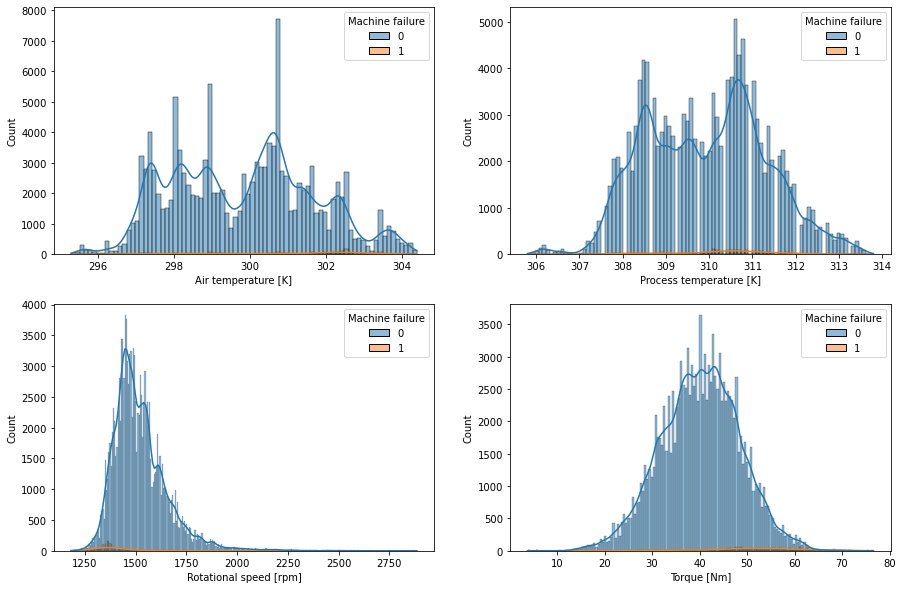

In [ ]:
_, ax = plt.subplots(2,2, figsize=(15,10))
sns.histplot(data, x="Air temperature [K]", hue='Machine failure',kde=True, ax=ax[0,0])
sns.histplot(data, x="Process temperature [K]", hue='Machine failure',kde=True, ax=ax[0,1])
sns.histplot(data, x="Rotational speed [rpm]", hue='Machine failure',kde=True, ax=ax[1,0])
sns.histplot(data, x="Torque [Nm]", hue='Machine failure',kde=True, ax=ax[1,1])

<AxesSubplot:xlabel='Tool wear [min]', ylabel='Count'>

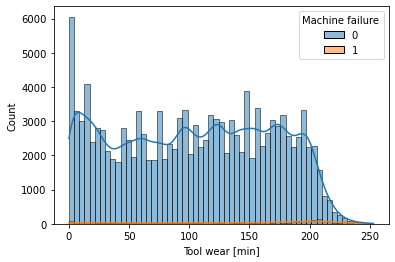

In [ ]:
sns.histplot(data, x="Tool wear [min]", hue='Machine failure',kde=True)

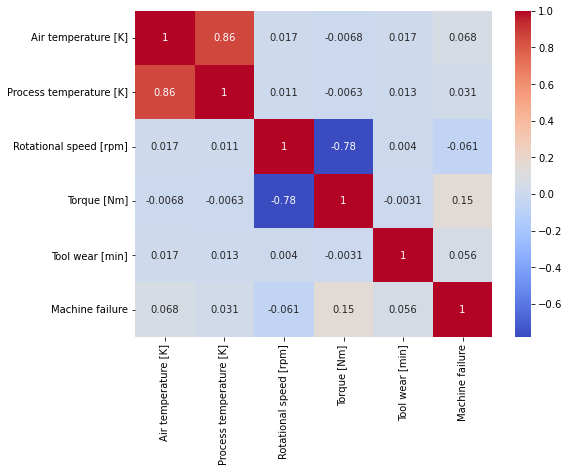

In [ ]:
numeric_columns = ["Air temperature [K]","Process temperature [K]","Rotational speed [rpm]","Torque [Nm]","Tool wear [min]"]
corr = data[numeric_columns+['Machine failure']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', xticklabels=corr.index, yticklabels=corr.columns)
plt.show()

# Data Preprocessing

In [ ]:
data = data.drop(['id','Product ID'], axis=1)

In [ ]:
data.drop(columns="RNF",inplace=True)

In [ ]:
new_names = {'Air temperature [K]':'Air temperature',
            'Process temperature [K]':'Process temperature',
            'Rotational speed [rpm]':'Rotational speed',
            'Torque [Nm]':'Torque',
            'Tool wear [min]':'Tool wear'}

data = data.rename(columns=new_names)

In [ ]:
data.isnull().any()

Type                   False
Air temperature        False
Process temperature    False
Rotational speed       False
Torque                 False
Tool wear              False
Machine failure        False
TWF                    False
HDF                    False
PWF                    False
OSF                    False
dtype: bool

In [ ]:
le = LabelEncoder()
scaler = MinMaxScaler()

num_cols = list(data.dtypes[(data.dtypes!='object')].index)
categorical_cols = ['Type']

le.fit(data[categorical_cols])
scaler.fit(data[num_cols])

data[categorical_cols] = data[categorical_cols].apply(le.transform)

data[num_cols] = scaler.transform(data[num_cols])



In [ ]:
data.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF
0,1,0.582418,0.4750,0.243402,0.443681,0.553360,0.0,0.0,0.0,0.0,0.0
1,2,0.802198,0.7875,0.339003,0.347527,0.790514,0.0,0.0,0.0,0.0,0.0
2,1,0.439560,0.3375,0.365982,0.311813,0.098814,0.0,0.0,0.0,0.0,0.0
3,1,0.626374,0.6375,0.201173,0.556319,0.778656,0.0,0.0,0.0,0.0,0.0
4,2,0.296703,0.4000,0.269795,0.434066,0.134387,0.0,0.0,0.0,0.0,0.0


# Model Building

In [ ]:
def evaluation(y_test,y_pred,model_name):
    metric = dict()
    metric['accuracy'] = accuracy_score(y_test, y_pred)
    metric['recall'] = recall_score(y_test, y_pred)
    metric['precision'] = precision_score(y_test, y_pred)
    metric['f1-score'] = f1_score(y_test, y_pred)

    confusion_mat = confusion_matrix(y_test, y_pred)
    class_labels = ['0', '1']

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_mat, annot=True, cmap="Blues", fmt="d", xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


    res = pd.DataFrame([metric])
    res.index = [f'{model_name}']
    return res

In [ ]:
df = data.copy()

X = df.drop(['Machine failure'], axis=1)
y = df['Machine failure']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((109143, 10), (27286, 10), (109143,), (27286,))

In [ ]:
results = pd.DataFrame()

Logistic Regression

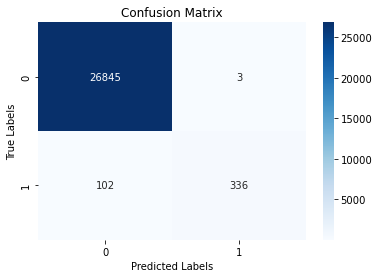

,accuracy,recall,precision,f1-score
LogisticRegression,0.996152,0.767123,0.99115,0.864865


In [ ]:
logistic_reg = LogisticRegression()
logistic_reg.fit(X_train, y_train)

y_pred = logistic_reg.predict(X_test)

results = results.append(evaluation(y_test,y_pred,'LogisticRegression'))
results

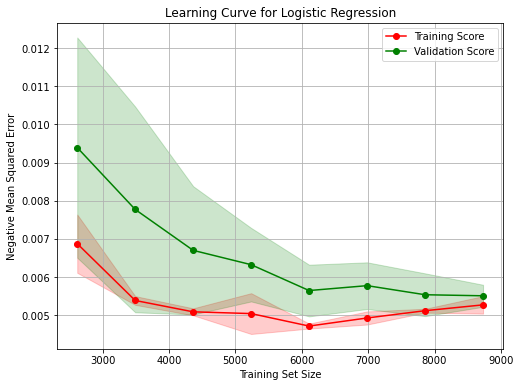

In [ ]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    logistic_reg, X_train, y_train, train_sizes=np.linspace(0.1,0.01,10)[::-1], cv=5, scoring='neg_mean_squared_error')

train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = -np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Score')
plt.plot(train_sizes, val_scores_mean, 'o-', color='g', label='Validation Score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='r')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.2, color='g')
plt.xlabel('Training Set Size')
plt.ylabel('Negative Mean Squared Error')
plt.title('Learning Curve for Logistic Regression')
plt.legend(loc='best')
plt.grid(True)
plt.show()

XGBoost Classifier

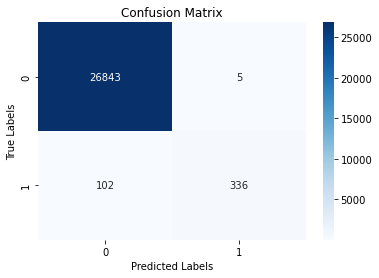

,accuracy,recall,precision,f1-score
LogisticRegression,0.996152,0.767123,0.991150,0.864865
XGBClassifier,0.996079,0.767123,0.985337,0.862644


In [ ]:
model = XGBClassifier(learning_rate=0.01, max_depth=10, n_estimators=300)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

results = results.append(evaluation(y_test,y_pred,'XGBClassifier'))
results

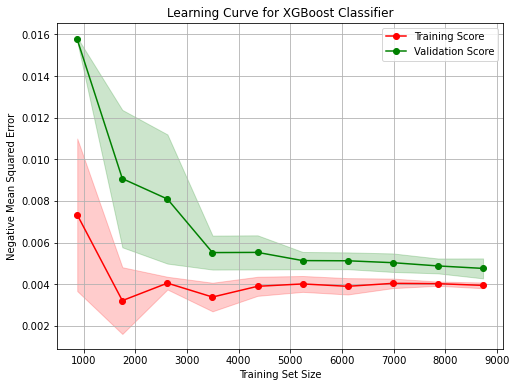

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train, train_sizes=np.linspace(0.1,0.01,10)[::-1], cv=5, scoring='neg_mean_squared_error')

train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = -np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Score')
plt.plot(train_sizes, val_scores_mean, 'o-', color='g', label='Validation Score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='r')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.2, color='g')
plt.xlabel('Training Set Size')
plt.ylabel('Negative Mean Squared Error')
plt.title('Learning Curve for XGBoost Classifier')
plt.legend(loc='best')
plt.grid(True)
plt.show()

CatBoost Classifier

0:	learn: 0.6664792	total: 235ms	remaining: 3m 54s
1:	learn: 0.6401772	total: 311ms	remaining: 2m 35s
2:	learn: 0.6166388	total: 367ms	remaining: 2m 2s
3:	learn: 0.5936617	total: 416ms	remaining: 1m 43s
4:	learn: 0.5725438	total: 477ms	remaining: 1m 34s
5:	learn: 0.5510675	total: 532ms	remaining: 1m 28s
6:	learn: 0.5292979	total: 586ms	remaining: 1m 23s
7:	learn: 0.5105844	total: 625ms	remaining: 1m 17s
8:	learn: 0.4919186	total: 669ms	remaining: 1m 13s
9:	learn: 0.4724679	total: 724ms	remaining: 1m 11s
10:	learn: 0.4544006	total: 861ms	remaining: 1m 17s
11:	learn: 0.4360794	total: 1.01s	remaining: 1m 22s
12:	learn: 0.4195377	total: 1.19s	remaining: 1m 30s
13:	learn: 0.4042764	total: 1.26s	remaining: 1m 28s
14:	learn: 0.3881883	total: 1.33s	remaining: 1m 27s
15:	learn: 0.3736072	total: 1.41s	remaining: 1m 26s
16:	learn: 0.3592638	total: 1.45s	remaining: 1m 23s
17:	learn: 0.3464879	total: 1.49s	remaining: 1m 21s
18:	learn: 0.3333025	total: 1.53s	remaining: 1m 19s
19:	learn: 0.3206388	to

165:	learn: 0.0253398	total: 8.97s	remaining: 45.1s
166:	learn: 0.0252552	total: 9.03s	remaining: 45.1s
167:	learn: 0.0251565	total: 9.09s	remaining: 45s
168:	learn: 0.0250637	total: 9.12s	remaining: 44.9s
169:	learn: 0.0249803	total: 9.16s	remaining: 44.7s
170:	learn: 0.0249077	total: 9.19s	remaining: 44.6s
171:	learn: 0.0248268	total: 9.23s	remaining: 44.4s
172:	learn: 0.0247531	total: 9.26s	remaining: 44.3s
173:	learn: 0.0246752	total: 9.33s	remaining: 44.3s
174:	learn: 0.0246189	total: 9.39s	remaining: 44.3s
175:	learn: 0.0245409	total: 9.47s	remaining: 44.4s
176:	learn: 0.0244700	total: 9.54s	remaining: 44.4s
177:	learn: 0.0243995	total: 9.63s	remaining: 44.5s
178:	learn: 0.0243383	total: 9.67s	remaining: 44.4s
179:	learn: 0.0242515	total: 9.71s	remaining: 44.2s
180:	learn: 0.0241883	total: 9.81s	remaining: 44.4s
181:	learn: 0.0241186	total: 9.89s	remaining: 44.4s
182:	learn: 0.0240659	total: 9.95s	remaining: 44.4s
183:	learn: 0.0240146	total: 9.99s	remaining: 44.3s
184:	learn: 0.

327:	learn: 0.0206386	total: 18s	remaining: 36.9s
328:	learn: 0.0206299	total: 18s	remaining: 36.8s
329:	learn: 0.0206224	total: 18.1s	remaining: 36.7s
330:	learn: 0.0206123	total: 18.1s	remaining: 36.6s
331:	learn: 0.0206031	total: 18.1s	remaining: 36.5s
332:	learn: 0.0205970	total: 18.2s	remaining: 36.5s
333:	learn: 0.0205871	total: 18.3s	remaining: 36.4s
334:	learn: 0.0205787	total: 18.3s	remaining: 36.3s
335:	learn: 0.0205717	total: 18.3s	remaining: 36.2s
336:	learn: 0.0205666	total: 18.4s	remaining: 36.1s
337:	learn: 0.0205573	total: 18.4s	remaining: 36.1s
338:	learn: 0.0205497	total: 18.5s	remaining: 36s
339:	learn: 0.0205366	total: 18.5s	remaining: 35.9s
340:	learn: 0.0205257	total: 18.6s	remaining: 35.9s
341:	learn: 0.0205162	total: 18.6s	remaining: 35.8s
342:	learn: 0.0205058	total: 18.7s	remaining: 35.7s
343:	learn: 0.0204982	total: 18.7s	remaining: 35.7s
344:	learn: 0.0204871	total: 18.8s	remaining: 35.6s
345:	learn: 0.0204782	total: 18.8s	remaining: 35.5s
346:	learn: 0.0204

489:	learn: 0.0196128	total: 24.9s	remaining: 25.9s
490:	learn: 0.0196087	total: 24.9s	remaining: 25.8s
491:	learn: 0.0196029	total: 25s	remaining: 25.8s
492:	learn: 0.0195993	total: 25s	remaining: 25.7s
493:	learn: 0.0195927	total: 25s	remaining: 25.6s
494:	learn: 0.0195851	total: 25.1s	remaining: 25.6s
495:	learn: 0.0195772	total: 25.1s	remaining: 25.5s
496:	learn: 0.0195723	total: 25.1s	remaining: 25.4s
497:	learn: 0.0195653	total: 25.2s	remaining: 25.4s
498:	learn: 0.0195593	total: 25.2s	remaining: 25.3s
499:	learn: 0.0195547	total: 25.2s	remaining: 25.2s
500:	learn: 0.0195502	total: 25.3s	remaining: 25.2s
501:	learn: 0.0195424	total: 25.3s	remaining: 25.1s
502:	learn: 0.0195380	total: 25.3s	remaining: 25s
503:	learn: 0.0195345	total: 25.4s	remaining: 25s
504:	learn: 0.0195302	total: 25.4s	remaining: 24.9s
505:	learn: 0.0195226	total: 25.5s	remaining: 24.9s
506:	learn: 0.0195195	total: 25.5s	remaining: 24.8s
507:	learn: 0.0195163	total: 25.6s	remaining: 24.7s
508:	learn: 0.0195086	

650:	learn: 0.0188713	total: 31.3s	remaining: 16.8s
651:	learn: 0.0188682	total: 31.3s	remaining: 16.7s
652:	learn: 0.0188645	total: 31.4s	remaining: 16.7s
653:	learn: 0.0188620	total: 31.4s	remaining: 16.6s
654:	learn: 0.0188586	total: 31.4s	remaining: 16.6s
655:	learn: 0.0188562	total: 31.5s	remaining: 16.5s
656:	learn: 0.0188526	total: 31.5s	remaining: 16.5s
657:	learn: 0.0188472	total: 31.6s	remaining: 16.4s
658:	learn: 0.0188448	total: 31.6s	remaining: 16.3s
659:	learn: 0.0188423	total: 31.6s	remaining: 16.3s
660:	learn: 0.0188375	total: 31.7s	remaining: 16.2s
661:	learn: 0.0188342	total: 31.7s	remaining: 16.2s
662:	learn: 0.0188303	total: 31.7s	remaining: 16.1s
663:	learn: 0.0188272	total: 31.8s	remaining: 16.1s
664:	learn: 0.0188187	total: 31.8s	remaining: 16s
665:	learn: 0.0188148	total: 31.9s	remaining: 16s
666:	learn: 0.0188123	total: 31.9s	remaining: 15.9s
667:	learn: 0.0188033	total: 31.9s	remaining: 15.9s
668:	learn: 0.0187993	total: 32s	remaining: 15.8s
669:	learn: 0.0187

810:	learn: 0.0182529	total: 37.3s	remaining: 8.7s
811:	learn: 0.0182501	total: 37.4s	remaining: 8.65s
812:	learn: 0.0182480	total: 37.4s	remaining: 8.61s
813:	learn: 0.0182454	total: 37.5s	remaining: 8.56s
814:	learn: 0.0182419	total: 37.5s	remaining: 8.51s
815:	learn: 0.0182374	total: 37.5s	remaining: 8.46s
816:	learn: 0.0182337	total: 37.6s	remaining: 8.42s
817:	learn: 0.0182314	total: 37.6s	remaining: 8.37s
818:	learn: 0.0182263	total: 37.6s	remaining: 8.32s
819:	learn: 0.0182237	total: 37.7s	remaining: 8.27s
820:	learn: 0.0182188	total: 37.7s	remaining: 8.22s
821:	learn: 0.0182158	total: 37.8s	remaining: 8.18s
822:	learn: 0.0182141	total: 37.8s	remaining: 8.13s
823:	learn: 0.0182073	total: 37.8s	remaining: 8.08s
824:	learn: 0.0182047	total: 37.9s	remaining: 8.03s
825:	learn: 0.0182007	total: 37.9s	remaining: 7.98s
826:	learn: 0.0181974	total: 37.9s	remaining: 7.94s
827:	learn: 0.0181913	total: 38s	remaining: 7.89s
828:	learn: 0.0181887	total: 38s	remaining: 7.84s
829:	learn: 0.018

973:	learn: 0.0177003	total: 43.4s	remaining: 1.16s
974:	learn: 0.0176982	total: 43.5s	remaining: 1.11s
975:	learn: 0.0176939	total: 43.5s	remaining: 1.07s
976:	learn: 0.0176919	total: 43.5s	remaining: 1.02s
977:	learn: 0.0176896	total: 43.6s	remaining: 980ms
978:	learn: 0.0176865	total: 43.6s	remaining: 936ms
979:	learn: 0.0176811	total: 43.7s	remaining: 891ms
980:	learn: 0.0176759	total: 43.7s	remaining: 846ms
981:	learn: 0.0176721	total: 43.7s	remaining: 801ms
982:	learn: 0.0176694	total: 43.8s	remaining: 757ms
983:	learn: 0.0176668	total: 43.8s	remaining: 712ms
984:	learn: 0.0176626	total: 43.8s	remaining: 667ms
985:	learn: 0.0176573	total: 43.9s	remaining: 623ms
986:	learn: 0.0176537	total: 43.9s	remaining: 578ms
987:	learn: 0.0176491	total: 43.9s	remaining: 534ms
988:	learn: 0.0176465	total: 44s	remaining: 489ms
989:	learn: 0.0176442	total: 44s	remaining: 444ms
990:	learn: 0.0176407	total: 44s	remaining: 400ms
991:	learn: 0.0176390	total: 44.1s	remaining: 355ms
992:	learn: 0.0176

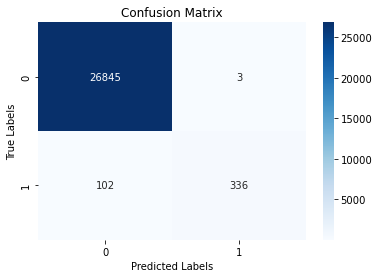

,accuracy,recall,precision,f1-score
LogisticRegression,0.996152,0.767123,0.991150,0.864865
XGBClassifier,0.996079,0.767123,0.985337,0.862644
CatBoostClassifier,0.996152,0.767123,0.991150,0.864865


In [ ]:
cat_model = CatBoostClassifier(depth=7, l2_leaf_reg= 1, learning_rate=0.01)
cat_model.fit(X_train, y_train)

y_pred = cat_model.predict(X_test)

results = results.append(evaluation(y_test,y_pred,'CatBoostClassifier'))
results

0:	learn: 0.6647972	total: 8.61ms	remaining: 8.6s
1:	learn: 0.6392087	total: 17ms	remaining: 8.49s
2:	learn: 0.6133355	total: 25.5ms	remaining: 8.47s
3:	learn: 0.5888385	total: 32.6ms	remaining: 8.11s
4:	learn: 0.5663808	total: 43.8ms	remaining: 8.71s
5:	learn: 0.5422159	total: 54.3ms	remaining: 8.99s
6:	learn: 0.5198464	total: 61.1ms	remaining: 8.67s
7:	learn: 0.4975189	total: 68.2ms	remaining: 8.45s
8:	learn: 0.4761477	total: 76.1ms	remaining: 8.38s
9:	learn: 0.4578802	total: 82.4ms	remaining: 8.15s
10:	learn: 0.4373719	total: 86.5ms	remaining: 7.77s
11:	learn: 0.4181058	total: 96.6ms	remaining: 7.95s
12:	learn: 0.4013058	total: 103ms	remaining: 7.83s
13:	learn: 0.3851165	total: 110ms	remaining: 7.71s
14:	learn: 0.3674768	total: 117ms	remaining: 7.68s
15:	learn: 0.3546387	total: 120ms	remaining: 7.4s
16:	learn: 0.3418553	total: 126ms	remaining: 7.31s
17:	learn: 0.3283831	total: 133ms	remaining: 7.26s
18:	learn: 0.3156645	total: 140ms	remaining: 7.21s
19:	learn: 0.3020130	total: 144ms

166:	learn: 0.0074354	total: 1.07s	remaining: 5.36s
167:	learn: 0.0073259	total: 1.08s	remaining: 5.35s
168:	learn: 0.0072538	total: 1.08s	remaining: 5.34s
169:	learn: 0.0072011	total: 1.09s	remaining: 5.33s
170:	learn: 0.0071121	total: 1.1s	remaining: 5.32s
171:	learn: 0.0070300	total: 1.1s	remaining: 5.31s
172:	learn: 0.0069448	total: 1.11s	remaining: 5.31s
173:	learn: 0.0068157	total: 1.11s	remaining: 5.29s
174:	learn: 0.0067607	total: 1.12s	remaining: 5.29s
175:	learn: 0.0066724	total: 1.13s	remaining: 5.28s
176:	learn: 0.0065637	total: 1.13s	remaining: 5.27s
177:	learn: 0.0064913	total: 1.14s	remaining: 5.26s
178:	learn: 0.0063865	total: 1.14s	remaining: 5.25s
179:	learn: 0.0063112	total: 1.15s	remaining: 5.24s
180:	learn: 0.0062944	total: 1.15s	remaining: 5.22s
181:	learn: 0.0062671	total: 1.16s	remaining: 5.21s
182:	learn: 0.0062490	total: 1.16s	remaining: 5.19s
183:	learn: 0.0061808	total: 1.17s	remaining: 5.18s
184:	learn: 0.0060812	total: 1.17s	remaining: 5.16s
185:	learn: 0.

349:	learn: 0.0016902	total: 2.13s	remaining: 3.95s
350:	learn: 0.0016795	total: 2.13s	remaining: 3.94s
351:	learn: 0.0016697	total: 2.14s	remaining: 3.93s
352:	learn: 0.0016529	total: 2.14s	remaining: 3.93s
353:	learn: 0.0016414	total: 2.15s	remaining: 3.92s
354:	learn: 0.0016325	total: 2.15s	remaining: 3.91s
355:	learn: 0.0016276	total: 2.16s	remaining: 3.91s
356:	learn: 0.0016169	total: 2.17s	remaining: 3.9s
357:	learn: 0.0016071	total: 2.17s	remaining: 3.89s
358:	learn: 0.0015926	total: 2.18s	remaining: 3.89s
359:	learn: 0.0015787	total: 2.18s	remaining: 3.88s
360:	learn: 0.0015728	total: 2.19s	remaining: 3.87s
361:	learn: 0.0015636	total: 2.19s	remaining: 3.87s
362:	learn: 0.0015508	total: 2.2s	remaining: 3.86s
363:	learn: 0.0015434	total: 2.21s	remaining: 3.86s
364:	learn: 0.0015396	total: 2.21s	remaining: 3.85s
365:	learn: 0.0015355	total: 2.22s	remaining: 3.85s
366:	learn: 0.0015317	total: 2.23s	remaining: 3.84s
367:	learn: 0.0015289	total: 2.23s	remaining: 3.83s
368:	learn: 0.

533:	learn: 0.0007282	total: 3.18s	remaining: 2.78s
534:	learn: 0.0007249	total: 3.19s	remaining: 2.77s
535:	learn: 0.0007244	total: 3.19s	remaining: 2.76s
536:	learn: 0.0007219	total: 3.19s	remaining: 2.75s
537:	learn: 0.0007194	total: 3.2s	remaining: 2.75s
538:	learn: 0.0007143	total: 3.21s	remaining: 2.74s
539:	learn: 0.0007135	total: 3.21s	remaining: 2.74s
540:	learn: 0.0007108	total: 3.22s	remaining: 2.73s
541:	learn: 0.0007068	total: 3.22s	remaining: 2.72s
542:	learn: 0.0007012	total: 3.23s	remaining: 2.72s
543:	learn: 0.0007003	total: 3.24s	remaining: 2.71s
544:	learn: 0.0006987	total: 3.24s	remaining: 2.71s
545:	learn: 0.0006940	total: 3.25s	remaining: 2.7s
546:	learn: 0.0006907	total: 3.26s	remaining: 2.7s
547:	learn: 0.0006894	total: 3.26s	remaining: 2.69s
548:	learn: 0.0006881	total: 3.27s	remaining: 2.68s
549:	learn: 0.0006864	total: 3.27s	remaining: 2.68s
550:	learn: 0.0006832	total: 3.28s	remaining: 2.67s
551:	learn: 0.0006802	total: 3.29s	remaining: 2.67s
552:	learn: 0.0

717:	learn: 0.0004240	total: 4.24s	remaining: 1.66s
718:	learn: 0.0004227	total: 4.24s	remaining: 1.66s
719:	learn: 0.0004219	total: 4.25s	remaining: 1.65s
720:	learn: 0.0004207	total: 4.25s	remaining: 1.65s
721:	learn: 0.0004204	total: 4.26s	remaining: 1.64s
722:	learn: 0.0004199	total: 4.27s	remaining: 1.64s
723:	learn: 0.0004193	total: 4.27s	remaining: 1.63s
724:	learn: 0.0004183	total: 4.28s	remaining: 1.62s
725:	learn: 0.0004171	total: 4.29s	remaining: 1.62s
726:	learn: 0.0004166	total: 4.29s	remaining: 1.61s
727:	learn: 0.0004150	total: 4.3s	remaining: 1.6s
728:	learn: 0.0004143	total: 4.3s	remaining: 1.6s
729:	learn: 0.0004132	total: 4.31s	remaining: 1.59s
730:	learn: 0.0004114	total: 4.32s	remaining: 1.59s
731:	learn: 0.0004110	total: 4.32s	remaining: 1.58s
732:	learn: 0.0004094	total: 4.33s	remaining: 1.58s
733:	learn: 0.0004085	total: 4.33s	remaining: 1.57s
734:	learn: 0.0004072	total: 4.34s	remaining: 1.56s
735:	learn: 0.0004059	total: 4.35s	remaining: 1.56s
736:	learn: 0.00

...

167:	learn: 0.0256172	total: 1.46s	remaining: 7.23s
168:	learn: 0.0255032	total: 1.47s	remaining: 7.22s
169:	learn: 0.0254410	total: 1.47s	remaining: 7.2s
170:	learn: 0.0252979	total: 1.48s	remaining: 7.18s
171:	learn: 0.0252206	total: 1.49s	remaining: 7.16s
172:	learn: 0.0250915	total: 1.5s	remaining: 7.15s
173:	learn: 0.0249778	total: 1.5s	remaining: 7.14s
174:	learn: 0.0249108	total: 1.51s	remaining: 7.13s
175:	learn: 0.0248036	total: 1.52s	remaining: 7.12s
176:	learn: 0.0247166	total: 1.53s	remaining: 7.11s
177:	learn: 0.0246087	total: 1.54s	remaining: 7.1s
178:	learn: 0.0244817	total: 1.55s	remaining: 7.09s
179:	learn: 0.0243813	total: 1.55s	remaining: 7.08s
180:	learn: 0.0243027	total: 1.56s	remaining: 7.07s
181:	learn: 0.0241930	total: 1.57s	remaining: 7.06s
182:	learn: 0.0241027	total: 1.58s	remaining: 7.05s
183:	learn: 0.0240006	total: 1.59s	remaining: 7.04s
184:	learn: 0.0239101	total: 1.59s	remaining: 7.03s
185:	learn: 0.0238303	total: 1.6s	remaining: 7.02s
186:	learn: 0.023

342:	learn: 0.0173580	total: 2.93s	remaining: 5.62s
343:	learn: 0.0173407	total: 2.94s	remaining: 5.61s
344:	learn: 0.0173298	total: 2.95s	remaining: 5.6s
345:	learn: 0.0173230	total: 2.95s	remaining: 5.58s
346:	learn: 0.0173065	total: 2.96s	remaining: 5.58s
347:	learn: 0.0172833	total: 2.97s	remaining: 5.56s
348:	learn: 0.0172642	total: 2.98s	remaining: 5.55s
349:	learn: 0.0172469	total: 2.98s	remaining: 5.54s
350:	learn: 0.0172266	total: 2.99s	remaining: 5.54s
351:	learn: 0.0172137	total: 3s	remaining: 5.53s
352:	learn: 0.0171881	total: 3.01s	remaining: 5.51s
353:	learn: 0.0171702	total: 3.02s	remaining: 5.5s
354:	learn: 0.0171547	total: 3.02s	remaining: 5.5s
355:	learn: 0.0171300	total: 3.03s	remaining: 5.49s
356:	learn: 0.0171176	total: 3.04s	remaining: 5.48s
357:	learn: 0.0171032	total: 3.05s	remaining: 5.47s
358:	learn: 0.0170761	total: 3.06s	remaining: 5.46s
359:	learn: 0.0170445	total: 3.07s	remaining: 5.45s
360:	learn: 0.0170342	total: 3.07s	remaining: 5.44s
361:	learn: 0.0170

503:	learn: 0.0147341	total: 4.23s	remaining: 4.17s
504:	learn: 0.0147088	total: 4.24s	remaining: 4.16s
505:	learn: 0.0146934	total: 4.25s	remaining: 4.15s
506:	learn: 0.0146697	total: 4.25s	remaining: 4.14s
507:	learn: 0.0146564	total: 4.26s	remaining: 4.13s
508:	learn: 0.0146286	total: 4.27s	remaining: 4.12s
509:	learn: 0.0145984	total: 4.28s	remaining: 4.11s
510:	learn: 0.0145853	total: 4.29s	remaining: 4.1s
511:	learn: 0.0145668	total: 4.3s	remaining: 4.09s
512:	learn: 0.0145425	total: 4.3s	remaining: 4.08s
513:	learn: 0.0145244	total: 4.31s	remaining: 4.08s
514:	learn: 0.0145141	total: 4.32s	remaining: 4.07s
515:	learn: 0.0144975	total: 4.33s	remaining: 4.06s
516:	learn: 0.0144816	total: 4.33s	remaining: 4.05s
517:	learn: 0.0144639	total: 4.34s	remaining: 4.04s
518:	learn: 0.0144531	total: 4.35s	remaining: 4.03s
519:	learn: 0.0144433	total: 4.36s	remaining: 4.02s
520:	learn: 0.0144311	total: 4.37s	remaining: 4.01s
521:	learn: 0.0144154	total: 4.37s	remaining: 4s
522:	learn: 0.0143

681:	learn: 0.0120113	total: 5.67s	remaining: 2.64s
682:	learn: 0.0120020	total: 5.68s	remaining: 2.63s
683:	learn: 0.0119876	total: 5.68s	remaining: 2.63s
684:	learn: 0.0119779	total: 5.69s	remaining: 2.62s
685:	learn: 0.0119587	total: 5.7s	remaining: 2.61s
686:	learn: 0.0119397	total: 5.71s	remaining: 2.6s
687:	learn: 0.0119175	total: 5.72s	remaining: 2.59s
688:	learn: 0.0118953	total: 5.72s	remaining: 2.58s
689:	learn: 0.0118870	total: 5.73s	remaining: 2.58s
690:	learn: 0.0118820	total: 5.74s	remaining: 2.57s
691:	learn: 0.0118570	total: 5.75s	remaining: 2.56s
692:	learn: 0.0118371	total: 5.76s	remaining: 2.55s
693:	learn: 0.0118158	total: 5.77s	remaining: 2.54s
694:	learn: 0.0118073	total: 5.77s	remaining: 2.53s
695:	learn: 0.0117928	total: 5.78s	remaining: 2.53s
696:	learn: 0.0117682	total: 5.79s	remaining: 2.52s
697:	learn: 0.0117451	total: 5.8s	remaining: 2.51s
698:	learn: 0.0117163	total: 5.81s	remaining: 2.5s
699:	learn: 0.0117131	total: 5.81s	remaining: 2.49s
700:	learn: 0.01

861:	learn: 0.0096422	total: 7.15s	remaining: 1.14s
862:	learn: 0.0096356	total: 7.16s	remaining: 1.14s
863:	learn: 0.0096297	total: 7.17s	remaining: 1.13s
864:	learn: 0.0096114	total: 7.17s	remaining: 1.12s
865:	learn: 0.0096025	total: 7.18s	remaining: 1.11s
866:	learn: 0.0095823	total: 7.19s	remaining: 1.1s
867:	learn: 0.0095665	total: 7.2s	remaining: 1.09s
868:	learn: 0.0095523	total: 7.21s	remaining: 1.09s
869:	learn: 0.0095371	total: 7.22s	remaining: 1.08s
870:	learn: 0.0095203	total: 7.22s	remaining: 1.07s
871:	learn: 0.0095177	total: 7.23s	remaining: 1.06s
872:	learn: 0.0095119	total: 7.24s	remaining: 1.05s
873:	learn: 0.0095041	total: 7.25s	remaining: 1.04s
874:	learn: 0.0094879	total: 7.26s	remaining: 1.04s
875:	learn: 0.0094760	total: 7.27s	remaining: 1.03s
876:	learn: 0.0094736	total: 7.27s	remaining: 1.02s
877:	learn: 0.0094622	total: 7.28s	remaining: 1.01s
878:	learn: 0.0094509	total: 7.29s	remaining: 1s
879:	learn: 0.0094429	total: 7.3s	remaining: 995ms
880:	learn: 0.0094

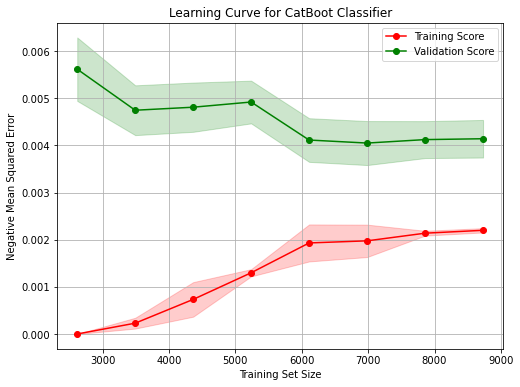

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    cat_model, X_train, y_train, train_sizes=np.linspace(0.1,0.01,10)[::-1], cv=5, scoring='neg_mean_squared_error')

train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = -np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Score')
plt.plot(train_sizes, val_scores_mean, 'o-', color='g', label='Validation Score')
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2, color='r')
plt.fill_between(train_sizes, val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std, alpha=0.2, color='g')
plt.xlabel('Training Set Size')
plt.ylabel('Negative Mean Squared Error')
plt.title('Learning Curve for CatBoot Classifier')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Train with Oversampled data

In [ ]:
ros = RandomOverSampler(random_state=42)
X, y = ros.fit_resample(X_train, y_train)

In [ ]:
oversampling_results = pd.DataFrame()

Logistic Regression

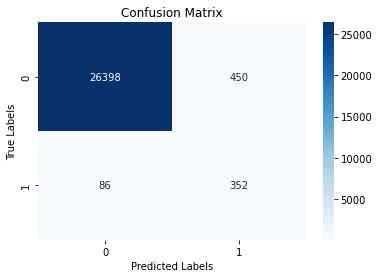

,accuracy,recall,precision,f1-score
LogisticRegression,0.980356,0.803653,0.438903,0.567742


In [ ]:
logistic_reg_s = LogisticRegression()
logistic_reg_s.fit(X,y)

y_pred = logistic_reg_s.predict(X_test)

oversampling_results = oversampling_results.append(evaluation(y_test,y_pred,'LogisticRegression'))
oversampling_results


XGBoost Classifier

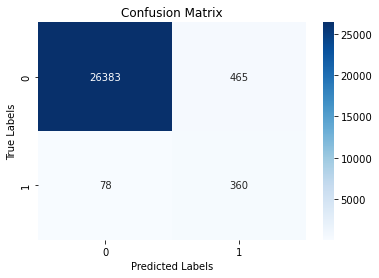

,accuracy,recall,precision,f1-score
LogisticRegression,0.980356,0.803653,0.438903,0.567742
XGBClassifier,0.980100,0.821918,0.436364,0.570071


In [ ]:
model = XGBClassifier(learning_rate=0.01, max_depth=10, n_estimators=300)
model.fit(X, y)

y_pred = model.predict(X_test)

oversampling_results = oversampling_results.append(evaluation(y_test,y_pred,'XGBClassifier'))
oversampling_results

CatBoos Classifier

0:	learn: 0.6723772	total: 34.8ms	remaining: 34.8s
1:	learn: 0.6526319	total: 68.3ms	remaining: 34.1s
2:	learn: 0.6344757	total: 107ms	remaining: 35.5s
3:	learn: 0.6164203	total: 144ms	remaining: 36s
4:	learn: 0.5993114	total: 183ms	remaining: 36.5s
5:	learn: 0.5833099	total: 224ms	remaining: 37.1s
6:	learn: 0.5680196	total: 276ms	remaining: 39.2s
7:	learn: 0.5535369	total: 327ms	remaining: 40.6s
8:	learn: 0.5397657	total: 364ms	remaining: 40.1s
9:	learn: 0.5266437	total: 399ms	remaining: 39.5s
10:	learn: 0.5143470	total: 440ms	remaining: 39.6s
11:	learn: 0.5026477	total: 479ms	remaining: 39.4s
12:	learn: 0.4915812	total: 527ms	remaining: 40s
13:	learn: 0.4810690	total: 566ms	remaining: 39.8s
14:	learn: 0.4711214	total: 606ms	remaining: 39.8s
15:	learn: 0.4616826	total: 643ms	remaining: 39.6s
16:	learn: 0.4542762	total: 682ms	remaining: 39.5s
17:	learn: 0.4469098	total: 721ms	remaining: 39.3s
18:	learn: 0.4400834	total: 769ms	remaining: 39.7s
19:	learn: 0.4321112	total: 806ms	remaining

163:	learn: 0.2191944	total: 6.77s	remaining: 34.5s
164:	learn: 0.2189121	total: 6.82s	remaining: 34.5s
165:	learn: 0.2186539	total: 6.86s	remaining: 34.4s
166:	learn: 0.2183616	total: 6.89s	remaining: 34.4s
167:	learn: 0.2180455	total: 6.94s	remaining: 34.4s
168:	learn: 0.2177945	total: 6.98s	remaining: 34.3s
169:	learn: 0.2174847	total: 7.03s	remaining: 34.3s
170:	learn: 0.2171601	total: 7.07s	remaining: 34.3s
171:	learn: 0.2169377	total: 7.13s	remaining: 34.3s
172:	learn: 0.2166027	total: 7.18s	remaining: 34.3s
173:	learn: 0.2163452	total: 7.24s	remaining: 34.4s
174:	learn: 0.2160974	total: 7.3s	remaining: 34.4s
175:	learn: 0.2158066	total: 7.35s	remaining: 34.4s
176:	learn: 0.2155162	total: 7.39s	remaining: 34.4s
177:	learn: 0.2152628	total: 7.43s	remaining: 34.3s
178:	learn: 0.2150320	total: 7.47s	remaining: 34.3s
179:	learn: 0.2147983	total: 7.51s	remaining: 34.2s
180:	learn: 0.2145099	total: 7.55s	remaining: 34.2s
181:	learn: 0.2141889	total: 7.59s	remaining: 34.1s
182:	learn: 0

322:	learn: 0.1902860	total: 14.5s	remaining: 30.3s
323:	learn: 0.1901665	total: 14.5s	remaining: 30.3s
324:	learn: 0.1900112	total: 14.6s	remaining: 30.2s
325:	learn: 0.1898385	total: 14.6s	remaining: 30.2s
326:	learn: 0.1897333	total: 14.7s	remaining: 30.2s
327:	learn: 0.1895958	total: 14.7s	remaining: 30.1s
328:	learn: 0.1894511	total: 14.8s	remaining: 30.2s
329:	learn: 0.1893436	total: 14.9s	remaining: 30.3s
330:	learn: 0.1892239	total: 15s	remaining: 30.4s
331:	learn: 0.1891203	total: 15.1s	remaining: 30.4s
332:	learn: 0.1890197	total: 15.2s	remaining: 30.4s
333:	learn: 0.1889172	total: 15.3s	remaining: 30.4s
334:	learn: 0.1888009	total: 15.3s	remaining: 30.5s
335:	learn: 0.1886590	total: 15.4s	remaining: 30.5s
336:	learn: 0.1885655	total: 15.5s	remaining: 30.5s
337:	learn: 0.1884511	total: 15.6s	remaining: 30.5s
338:	learn: 0.1883267	total: 15.6s	remaining: 30.4s
339:	learn: 0.1882100	total: 15.7s	remaining: 30.4s
340:	learn: 0.1881199	total: 15.7s	remaining: 30.4s
341:	learn: 0.

486:	learn: 0.1723373	total: 22.9s	remaining: 24.1s
487:	learn: 0.1722329	total: 22.9s	remaining: 24s
488:	learn: 0.1720982	total: 23s	remaining: 24s
489:	learn: 0.1719690	total: 23s	remaining: 23.9s
490:	learn: 0.1718937	total: 23.1s	remaining: 23.9s
491:	learn: 0.1717773	total: 23.1s	remaining: 23.9s
492:	learn: 0.1716960	total: 23.2s	remaining: 23.8s
493:	learn: 0.1716087	total: 23.2s	remaining: 23.8s
494:	learn: 0.1715258	total: 23.3s	remaining: 23.8s
495:	learn: 0.1714154	total: 23.4s	remaining: 23.8s
496:	learn: 0.1713209	total: 23.4s	remaining: 23.7s
497:	learn: 0.1712167	total: 23.5s	remaining: 23.7s
498:	learn: 0.1711375	total: 23.6s	remaining: 23.7s
499:	learn: 0.1710550	total: 23.6s	remaining: 23.6s
500:	learn: 0.1709467	total: 23.7s	remaining: 23.6s
501:	learn: 0.1708012	total: 23.7s	remaining: 23.6s
502:	learn: 0.1707216	total: 23.8s	remaining: 23.5s
503:	learn: 0.1706611	total: 23.9s	remaining: 23.5s
504:	learn: 0.1705729	total: 23.9s	remaining: 23.4s
505:	learn: 0.170495

647:	learn: 0.1565252	total: 32.2s	remaining: 17.5s
648:	learn: 0.1564147	total: 32.3s	remaining: 17.5s
649:	learn: 0.1563299	total: 32.3s	remaining: 17.4s
650:	learn: 0.1562350	total: 32.4s	remaining: 17.3s
651:	learn: 0.1561461	total: 32.4s	remaining: 17.3s
652:	learn: 0.1560355	total: 32.4s	remaining: 17.2s
653:	learn: 0.1559523	total: 32.5s	remaining: 17.2s
654:	learn: 0.1558545	total: 32.5s	remaining: 17.1s
655:	learn: 0.1557965	total: 32.6s	remaining: 17.1s
656:	learn: 0.1556967	total: 32.6s	remaining: 17s
657:	learn: 0.1555867	total: 32.6s	remaining: 17s
658:	learn: 0.1555095	total: 32.7s	remaining: 16.9s
659:	learn: 0.1554366	total: 32.7s	remaining: 16.9s
660:	learn: 0.1553561	total: 32.8s	remaining: 16.8s
661:	learn: 0.1552879	total: 32.8s	remaining: 16.7s
662:	learn: 0.1551742	total: 32.8s	remaining: 16.7s
663:	learn: 0.1551056	total: 32.9s	remaining: 16.6s
664:	learn: 0.1550234	total: 32.9s	remaining: 16.6s
665:	learn: 0.1549721	total: 33s	remaining: 16.5s
666:	learn: 0.1548

806:	learn: 0.1430665	total: 38.5s	remaining: 9.22s
807:	learn: 0.1430031	total: 38.6s	remaining: 9.17s
808:	learn: 0.1429386	total: 38.6s	remaining: 9.12s
809:	learn: 0.1428474	total: 38.6s	remaining: 9.07s
810:	learn: 0.1427717	total: 38.7s	remaining: 9.02s
811:	learn: 0.1427259	total: 38.7s	remaining: 8.97s
812:	learn: 0.1426329	total: 38.8s	remaining: 8.92s
813:	learn: 0.1425539	total: 38.8s	remaining: 8.87s
814:	learn: 0.1424948	total: 38.8s	remaining: 8.82s
815:	learn: 0.1424509	total: 38.9s	remaining: 8.77s
816:	learn: 0.1423754	total: 38.9s	remaining: 8.72s
817:	learn: 0.1422942	total: 39s	remaining: 8.67s
818:	learn: 0.1422099	total: 39s	remaining: 8.62s
819:	learn: 0.1421382	total: 39s	remaining: 8.57s
820:	learn: 0.1420480	total: 39.1s	remaining: 8.52s
821:	learn: 0.1419517	total: 39.1s	remaining: 8.47s
822:	learn: 0.1419025	total: 39.1s	remaining: 8.42s
823:	learn: 0.1418010	total: 39.2s	remaining: 8.37s
824:	learn: 0.1417402	total: 39.2s	remaining: 8.32s
825:	learn: 0.1416

965:	learn: 0.1315473	total: 45s	remaining: 1.58s
966:	learn: 0.1314366	total: 45.1s	remaining: 1.54s
967:	learn: 0.1313657	total: 45.1s	remaining: 1.49s
968:	learn: 0.1312904	total: 45.1s	remaining: 1.44s
969:	learn: 0.1312024	total: 45.2s	remaining: 1.4s
970:	learn: 0.1311451	total: 45.2s	remaining: 1.35s
971:	learn: 0.1310594	total: 45.3s	remaining: 1.3s
972:	learn: 0.1310260	total: 45.3s	remaining: 1.26s
973:	learn: 0.1309681	total: 45.3s	remaining: 1.21s
974:	learn: 0.1308686	total: 45.4s	remaining: 1.16s
975:	learn: 0.1308138	total: 45.4s	remaining: 1.12s
976:	learn: 0.1307586	total: 45.5s	remaining: 1.07s
977:	learn: 0.1306923	total: 45.5s	remaining: 1.02s
978:	learn: 0.1306061	total: 45.5s	remaining: 977ms
979:	learn: 0.1305556	total: 45.6s	remaining: 930ms
980:	learn: 0.1304525	total: 45.6s	remaining: 884ms
981:	learn: 0.1303785	total: 45.7s	remaining: 837ms
982:	learn: 0.1303301	total: 45.7s	remaining: 790ms
983:	learn: 0.1302388	total: 45.7s	remaining: 744ms
984:	learn: 0.13

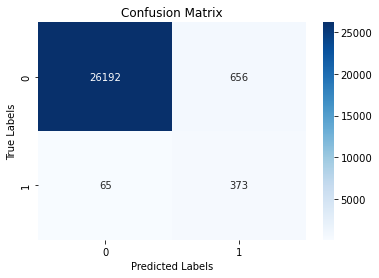

,accuracy,recall,precision,f1-score
LogisticRegression,0.980356,0.803653,0.438903,0.567742
XGBClassifier,0.980100,0.821918,0.436364,0.570071
CatBoostClassifier,0.973576,0.851598,0.362488,0.508521


In [ ]:
cat_model = CatBoostClassifier(depth=7, l2_leaf_reg= 1, learning_rate=0.01)
cat_model.fit(X, y)

y_pred = cat_model.predict(X_test)

oversampling_results = oversampling_results.append(evaluation(y_test,y_pred,'CatBoostClassifier'))
oversampling_results

# Comparing Results

In [ ]:
compare_results = pd.DataFrame()
compare_results['Accuracy without_oversampling'] = results['accuracy']
compare_results['Accuracy with_oversampling'] = oversampling_results['accuracy']

compare_results['Recall without_oversampling'] = results['recall']
compare_results['Recall with_oversampling'] = oversampling_results['recall']

compare_results['Precision without_oversampling'] = results['precision']
compare_results['Precision with_oversampling'] = oversampling_results['precision']

compare_results['F1-Score without_oversampling'] = results['f1-score']
compare_results['F1-Score with_oversampling'] = oversampling_results['f1-score']
compare_results

,Accuracy without_oversampling,Accuracy with_oversampling,Recall without_oversampling,Recall with_oversampling,Precision without_oversampling,Precision with_oversampling,F1-Score without_oversampling,F1-Score with_oversampling
LogisticRegression,0.996152,0.980356,0.767123,0.803653,0.991150,0.438903,0.864865,0.567742
XGBClassifier,0.996079,0.980100,0.767123,0.821918,0.985337,0.436364,0.862644,0.570071
CatBoostClassifier,0.996152,0.973576,0.767123,0.851598,0.991150,0.362488,0.864865,0.508521


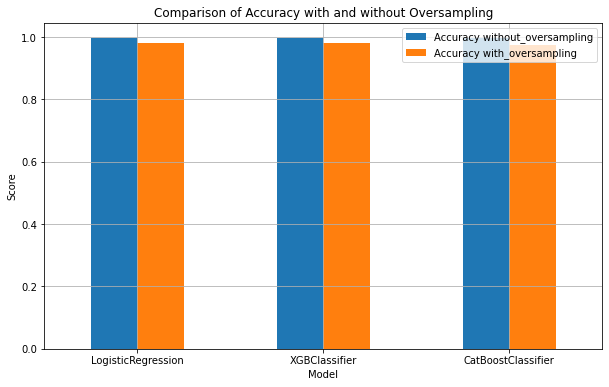

In [ ]:
compare_results[['Accuracy without_oversampling', 'Accuracy with_oversampling']].plot(
    kind='bar', figsize=(10, 6))
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Comparison of Accuracy with and without Oversampling')
plt.legend(loc='best')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

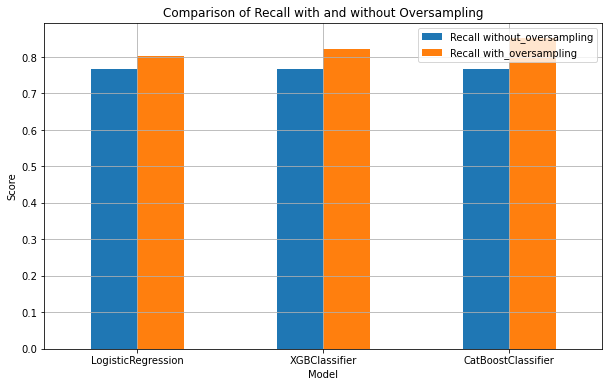

In [ ]:
compare_results[['Recall without_oversampling', 'Recall with_oversampling',]].plot(
    kind='bar', figsize=(10, 6))

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Comparison of Recall with and without Oversampling')
plt.legend(loc='best')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

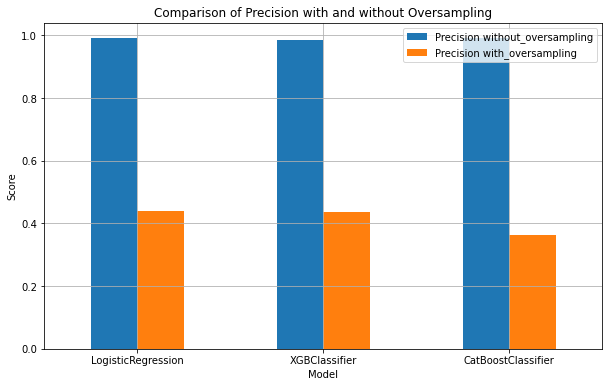

In [ ]:
compare_results[['Precision without_oversampling', 'Precision with_oversampling',]].plot(
    kind='bar', figsize=(10, 6))

plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.title('Comparison of Precision with and without Oversampling')
plt.legend(loc='best')
plt.grid(True)
plt.show()

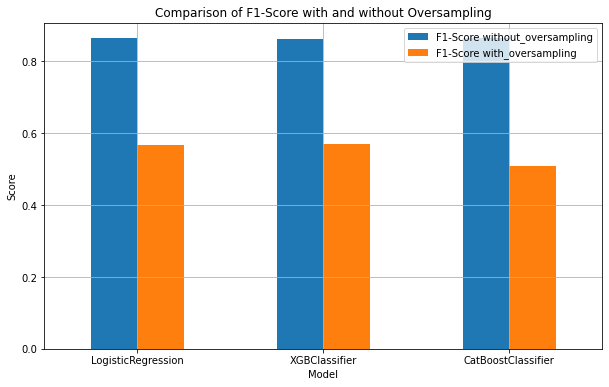

In [ ]:
compare_results[['F1-Score without_oversampling', 'F1-Score with_oversampling']].plot(
    kind='bar', figsize=(10, 6))

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Comparison of F1-Score with and without Oversampling')
plt.legend(loc='best')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

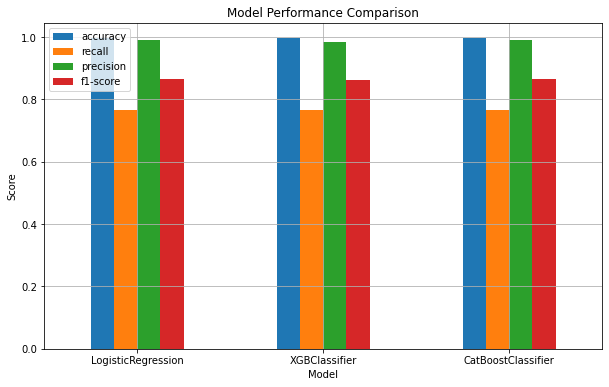

In [ ]:
results.plot(kind='bar', figsize=(10, 6))
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend(loc='best')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()